In [ ]:
import pygame as pg
import sympy as sp

pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html


# Inverted Pendulum (or segway model)

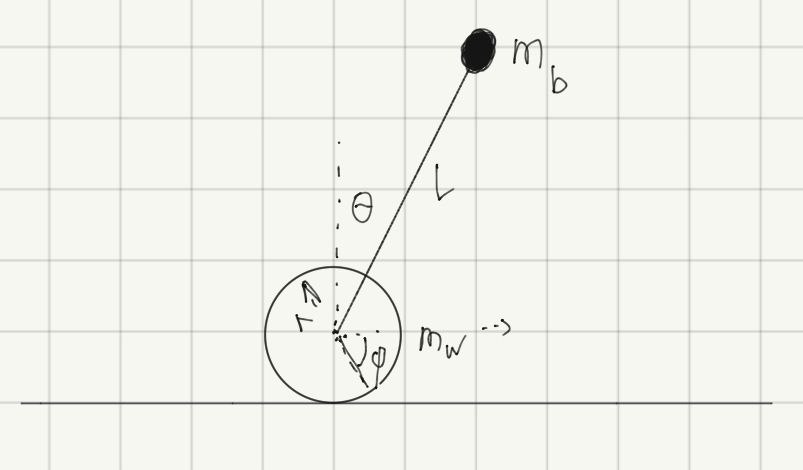

We assume that there is a rotation without slipping. Thus:
$$x_{wheel}=rϕ$$

## Generalized coordinates

To represent this system we need only 2 generalized coordinates: $\begin{bmatrix} \theta & \phi \end{bmatrix}^T$

We will consider a system of 2 bodies: wheel and body (or pendulum) attached to the wheel

Let's consider kinematics of a body, since it will simplify kinetic energy related calculations:
$$x_{body}=r\phi+l \sin(\theta)$$
$$y_{body}=r + l \cos(\theta)$$
Therefore, we get the following velocity equation:
$$\dot x_{body}=r\dot\phi+\dot \theta l \cos(\theta)$$
$$\dot y_{body}=-\dot\theta l \sin(\theta)$$
$$v_{body}^2=\dot x^2_{body}+\dot y^2_{body}=r^2\dot \phi^2 + \dot \theta^2 l^2 + r\dot \phi \dot \theta l \cos(\theta)$$

In [ ]:
r, l, t = sp.symbols('r, l, t')
theta, phi = sp.Function('\\theta')(t), sp.Function('\phi')(t)
x = r*phi + l*sp.sin(theta)
y = r + l*sp.cos(theta)
dx = sp.diff(x, t)
dy = sp.diff(y, t)
v2 = sp.simplify(dx ** 2 + dy ** 2)
v2

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_6868/2641271840.py:2: SyntaxWarning: invalid escape sequence '\p'
  theta, phi = sp.Function('\\theta')(t), sp.Function('\phi')(t)


l**2*Derivative(\theta(t), t)**2 + 2*l*r*cos(\theta(t))*Derivative(\phi(t), t)*Derivative(\theta(t), t) + r**2*Derivative(\phi(t), t)**2

## Kinetic Energy

In [ ]:
mb, Ib, mw, Iw = sp.symbols('m_b, I_b, m_w, I_w')
Tbody = mb * v2 / 2 + Ib * sp.diff(theta, t) ** 2 / 2
Twheel = mw * r **2 * sp.diff(phi, t)**2 /2 + Iw * sp.diff(phi, t) ** 2 /2

T = sp.simplify(Tbody + Twheel)
T

I_b*Derivative(\theta(t), t)**2/2 + I_w*Derivative(\phi(t), t)**2/2 + m_b*(l**2*Derivative(\theta(t), t)**2 + 2*l*r*cos(\theta(t))*Derivative(\phi(t), t)*Derivative(\theta(t), t) + r**2*Derivative(\phi(t), t)**2)/2 + m_w*r**2*Derivative(\phi(t), t)**2/2

In [ ]:
sp.latex(T)

'\\frac{I_{b} \\left(\\frac{d}{d t} \\theta{\\left(t \\right)}\\right)^{2}}{2} + \\frac{I_{w} \\left(\\frac{d}{d t} \\phi{\\left(t \\right)}\\right)^{2}}{2} + \\frac{m_{b} \\left(l^{2} \\left(\\frac{d}{d t} \\theta{\\left(t \\right)}\\right)^{2} + 2 l r \\cos{\\left(\\theta{\\left(t \\right)} \\right)} \\frac{d}{d t} \\phi{\\left(t \\right)} \\frac{d}{d t} \\theta{\\left(t \\right)} + r^{2} \\left(\\frac{d}{d t} \\phi{\\left(t \\right)}\\right)^{2}\\right)}{2} + \\frac{m_{w} r^{2} \\left(\\frac{d}{d t} \\phi{\\left(t \\right)}\\right)^{2}}{2}'

## Potential energy

In [ ]:
g = 9.8
V = mb * g * y
V

9.8*m_b*(l*cos(\theta(t)) + r)

In [ ]:
sp.latex(V)

'9.8 m_{b} \\left(l \\cos{\\left(\\theta{\\left(t \\right)} \\right)} + r\\right)'

## Lagrangian

In [ ]:
L = T - V
L

I_b*Derivative(\theta(t), t)**2/2 + I_w*Derivative(\phi(t), t)**2/2 - 9.8*m_b*(l*cos(\theta(t)) + r) + m_b*(l**2*Derivative(\theta(t), t)**2 + 2*l*r*cos(\theta(t))*Derivative(\phi(t), t)*Derivative(\theta(t), t) + r**2*Derivative(\phi(t), t)**2)/2 + m_w*r**2*Derivative(\phi(t), t)**2/2

In [ ]:
sp.latex(L)

'\\frac{I_{b} \\left(\\frac{d}{d t} \\theta{\\left(t \\right)}\\right)^{2}}{2} + \\frac{I_{w} \\left(\\frac{d}{d t} \\phi{\\left(t \\right)}\\right)^{2}}{2} - 9.8 m_{b} \\left(l \\cos{\\left(\\theta{\\left(t \\right)} \\right)} + r\\right) + \\frac{m_{b} \\left(l^{2} \\left(\\frac{d}{d t} \\theta{\\left(t \\right)}\\right)^{2} + 2 l r \\cos{\\left(\\theta{\\left(t \\right)} \\right)} \\frac{d}{d t} \\phi{\\left(t \\right)} \\frac{d}{d t} \\theta{\\left(t \\right)} + r^{2} \\left(\\frac{d}{d t} \\phi{\\left(t \\right)}\\right)^{2}\\right)}{2} + \\frac{m_{w} r^{2} \\left(\\frac{d}{d t} \\phi{\\left(t \\right)}\\right)^{2}}{2}'

In [ ]:
q = sp.Matrix([theta, phi])
q

Matrix([
[\theta(t)],
[  \phi(t)]])

In [ ]:
dq = sp.diff(q, t)
dq

Matrix([
[Derivative(\theta(t), t)],
[  Derivative(\phi(t), t)]])

In [ ]:
ddq = sp.diff(dq, t)
ddq

Matrix([
[Derivative(\theta(t), (t, 2))],
[  Derivative(\phi(t), (t, 2))]])

In [ ]:
eq = sp.simplify(L.diff(dq).diff(t) - L.diff(q))
eq

Matrix([
[                                         1.0*I_b*Derivative(\theta(t), (t, 2)) + 1.0*l**2*m_b*Derivative(\theta(t), (t, 2)) + 1.0*l*m_b*r*cos(\theta(t))*Derivative(\phi(t), (t, 2)) - 9.8*l*m_b*sin(\theta(t))],
[I_w*Derivative(\phi(t), (t, 2)) + m_b*r*(-l*sin(\theta(t))*Derivative(\theta(t), t)**2 + l*cos(\theta(t))*Derivative(\theta(t), (t, 2)) + r*Derivative(\phi(t), (t, 2))) + m_w*r**2*Derivative(\phi(t), (t, 2))]])

In [ ]:
sp.latex(eq)

'\\left[\\begin{matrix}1.0 I_{b} \\frac{d^{2}}{d t^{2}} \\theta{\\left(t \\right)} + 1.0 l^{2} m_{b} \\frac{d^{2}}{d t^{2}} \\theta{\\left(t \\right)} + 1.0 l m_{b} r \\cos{\\left(\\theta{\\left(t \\right)} \\right)} \\frac{d^{2}}{d t^{2}} \\phi{\\left(t \\right)} - 9.8 l m_{b} \\sin{\\left(\\theta{\\left(t \\right)} \\right)}\\\\I_{w} \\frac{d^{2}}{d t^{2}} \\phi{\\left(t \\right)} + m_{b} r \\left(- l \\sin{\\left(\\theta{\\left(t \\right)} \\right)} \\left(\\frac{d}{d t} \\theta{\\left(t \\right)}\\right)^{2} + l \\cos{\\left(\\theta{\\left(t \\right)} \\right)} \\frac{d^{2}}{d t^{2}} \\theta{\\left(t \\right)} + r \\frac{d^{2}}{d t^{2}} \\phi{\\left(t \\right)}\\right) + m_{w} r^{2} \\frac{d^{2}}{d t^{2}} \\phi{\\left(t \\right)}\\end{matrix}\\right]'

In [ ]:
M = eq.jacobian(ddq)
M

Matrix([
[1.0*I_b + 1.0*l**2*m_b, 1.0*l*m_b*r*cos(\theta(t))],
[l*m_b*r*cos(\theta(t)),  I_w + m_b*r**2 + m_w*r**2]])

In [ ]:
B*u - eq + M * ddq == B*u - H

False

In [ ]:
abob = (M.inv() * (eq - M * ddq)).simplify()

In [ ]:
sp.simplify(eq - M * ddq)

Matrix([
[                          -9.8*l*m_b*sin(\theta(t))],
[-l*m_b*r*sin(\theta(t))*Derivative(\theta(t), t)**2]])

In [ ]:
sp.simplify(M.inv() * (B* u - H))

Matrix([
[1.0*(-l*m_b*r*(l*m_b*r*sin(\theta(t))*Derivative(\theta(t), t)**2 + u)*cos(\theta(t)) + (9.8*l*m_b*sin(\theta(t)) - u)*(I_w + m_b*r**2 + m_w*r**2))/(I_b*I_w + I_b*m_b*r**2 + I_b*m_w*r**2 + I_w*l**2*m_b + l**2*m_b**2*r**2*sin(\theta(t))**2 + l**2*m_b*m_w*r**2)],
[           1.0*(-l*m_b*r*(9.8*l*m_b*sin(\theta(t)) - u)*cos(\theta(t)) + (I_b + l**2*m_b)*(l*m_b*r*sin(\theta(t))*Derivative(\theta(t), t)**2 + u))/(I_b*I_w + I_b*m_b*r**2 + I_b*m_w*r**2 + I_w*l**2*m_b + l**2*m_b**2*r**2*sin(\theta(t))**2 + l**2*m_b*m_w*r**2)]])

In [ ]:
abob

Matrix([
[          -1.0*l*m_b*(9.8*I_w - 1.0*l*m_b*r**2*cos(\theta(t))*Derivative(\theta(t), t)**2 + 9.8*m_b*r**2 + 9.8*m_w*r**2)*sin(\theta(t))/(I_b*I_w + I_b*m_b*r**2 + I_b*m_w*r**2 + I_w*l**2*m_b + l**2*m_b**2*r**2*sin(\theta(t))**2 + l**2*m_b*m_w*r**2)],
[-1.0*l*m_b*r*(1.0*I_b*Derivative(\theta(t), t)**2 + 1.0*l**2*m_b*Derivative(\theta(t), t)**2 - 9.8*l*m_b*cos(\theta(t)))*sin(\theta(t))/(I_b*I_w + I_b*m_b*r**2 + I_b*m_w*r**2 + I_w*l**2*m_b + l**2*m_b**2*r**2*sin(\theta(t))**2 + l**2*m_b*m_w*r**2)]])

In [ ]:
C = eq.jacobian(dq) / 2
C

Matrix([
[                                               0, 0],
[-l*m_b*r*sin(\theta(t))*Derivative(\theta(t), t), 0]])

In [ ]:
eq

Matrix([
[                                         1.0*I_b*Derivative(\theta(t), (t, 2)) + 1.0*l**2*m_b*Derivative(\theta(t), (t, 2)) + 1.0*l*m_b*r*cos(\theta(t))*Derivative(\phi(t), (t, 2)) - 9.8*l*m_b*sin(\theta(t))],
[I_w*Derivative(\phi(t), (t, 2)) + m_b*r*(-l*sin(\theta(t))*Derivative(\theta(t), t)**2 + l*cos(\theta(t))*Derivative(\theta(t), (t, 2)) + r*Derivative(\phi(t), (t, 2))) + m_w*r**2*Derivative(\phi(t), (t, 2))]])

In [ ]:
M * ddq

Matrix([
[1.0*l*m_b*r*cos(\theta(t))*Derivative(\phi(t), (t, 2)) + (1.0*I_b + 1.0*l**2*m_b)*Derivative(\theta(t), (t, 2))],
[ l*m_b*r*cos(\theta(t))*Derivative(\theta(t), (t, 2)) + (I_w + m_b*r**2 + m_w*r**2)*Derivative(\phi(t), (t, 2))]])

In [ ]:
G = sp.simplify(eq - M * ddq - C * dq)
G

Matrix([
[-9.8*l*m_b*sin(\theta(t))],
[                        0]])

We want to obtain the system in the form:
$$M(q)\ddot q + C(q, \dot q) \dot q + G(q) = \tau$$

The only part remained is to define torques $\tau$

In [ ]:
u = sp.symbols('u')

tau = sp.Matrix([u, -u])

In [ ]:
motion_eq = M * ddq + C * dq + G - tau
B = motion_eq.diff(u)
B

Matrix([
[-1],
[ 1]])

In [ ]:
H = C * dq + G

##

## State Space

In [ ]:
s = sp.Matrix([q, dq])
s

Matrix([
[               \theta(t)],
[                 \phi(t)],
[Derivative(\theta(t), t)],
[  Derivative(\phi(t), t)]])

In [ ]:
Minv = sp.symbols('M^{-1}')
Minv

M^{-1}

In [ ]:
B * u - H

Matrix([
[                          9.8*l*m_b*sin(\theta(t)) - u],
[l*m_b*r*sin(\theta(t))*Derivative(\theta(t), t)**2 + u]])

In [ ]:
Minv = sp.MatrixSymbol('M^{-1}', 2, 2)
ds = sp.Matrix([dq, M.inv() * (B* u - H)])
ds

Matrix([
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                     Derivative(\theta(t), t)],
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                       Derivative(\phi(t), t)],
[1.0*l*m_b*r*(l*m_b*r*sin(\th

In [ ]:
sp.latex(ds)

'\\left[\\begin{matrix}\\frac{d}{d t} \\theta{\\left(t \\right)}\\\\\\frac{d}{d t} \\phi{\\left(t \\right)}\\\\\\frac{1.0 l m_{b} r \\left(l m_{b} r \\sin{\\left(\\theta{\\left(t \\right)} \\right)} \\left(\\frac{d}{d t} \\theta{\\left(t \\right)}\\right)^{2} + u\\right) \\cos{\\left(\\theta{\\left(t \\right)} \\right)}}{- 1.0 I_{b} I_{w} - 1.0 I_{b} m_{b} r^{2} - 1.0 I_{b} m_{w} r^{2} - 1.0 I_{w} l^{2} m_{b} + 1.0 l^{2} m_{b}^{2} r^{2} \\cos^{2}{\\left(\\theta{\\left(t \\right)} \\right)} - 1.0 l^{2} m_{b}^{2} r^{2} - 1.0 l^{2} m_{b} m_{w} r^{2}} + \\frac{\\left(9.8 l m_{b} \\sin{\\left(\\theta{\\left(t \\right)} \\right)} - u\\right) \\left(- 1.0 I_{w} - 1.0 m_{b} r^{2} - 1.0 m_{w} r^{2}\\right)}{- 1.0 I_{b} I_{w} - 1.0 I_{b} m_{b} r^{2} - 1.0 I_{b} m_{w} r^{2} - 1.0 I_{w} l^{2} m_{b} + 1.0 l^{2} m_{b}^{2} r^{2} \\cos^{2}{\\left(\\theta{\\left(t \\right)} \\right)} - 1.0 l^{2} m_{b}^{2} r^{2} - 1.0 l^{2} m_{b} m_{w} r^{2}}\\\\\\frac{1.0 l m_{b} r \\left(9.8 l m_{b} \\sin{\\left(\\the

# LQR

In [ ]:
import numpy as np

## Checking that system is at equilibrium on upper position of pendulum with any angle of the wheel $\phi$

In [ ]:
s_des = sp.Matrix([0.0, phi, 0.0, 0.0])
sp.simplify(ds.subs(Minv, M.inv()).subs(u, 0.0).subs(dict(zip(s.values(), s_des.values()))))

## Defining mass and inertia properties

In [ ]:
mb_val = 10
mw_val = 1
l_val = 0.3
Ib_val = 1/3 * mb_val * l_val ** 2
r_val = 0.05
Iw_val = 0.7 * mw_val * r ** 2
mass_vars = [mb, mw, l, Ib, r, Iw]
mass_vals = [mb_val, mw_val, l_val, Ib_val, r_val, Iw_val]

## Linearizing system

In [ ]:
M.subs(dict(zip(mass_vars, mass_vals)))

In [ ]:
M_func = sp.lambdify([s], M.subs(dict(zip(mass_vars, mass_vals))))
# Minv_func = np.linalg.inv(M_func)

In [ ]:
A = ds.jacobian(s)
A

In [ ]:
A_func = sp.lambdify([Minv] + s.values(), A.subs(dict(zip(mass_vars, mass_vals))), 'numpy')

In [ ]:
A_func

In [ ]:
B = ds.diff(u)
B

In [ ]:
B_func = sp.lambdify([s.values(), Minv], B.subs(dict(zip(mass_vars, mass_vals))))

## Defining desired position

In [ ]:
s_des = np.array([0, np.pi, 0, 0])

### Checking Controlability around this point

In [ ]:
Minv_val = np.linalg.inv(M_func(s_des))
Minv_val

In [ ]:
A

In [ ]:
A = A.subs(dict(zip(mass_vars, mass_vals))).subs(Minv, sp.Matrix(Minv_val)).subs(dict(zip(s, s_des)))
# A_func = sp.lambdify([s], A , 'numpy')

In [ ]:
A.doit().evalf()

In [ ]:
A

In [ ]:
B = B.subs(dict(zip(mass_vars, mass_vals))).subs(Minv, sp.Matrix(Minv_val))
B_func = sp.lambdify([s], B)

In [ ]:
Minv_val

In [ ]:
A_val = A_func(s_des)
B_val = B_func(s_des)